In [43]:
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import plotly.express as px

In [44]:
# CONSTS
PLOT_WIDTH = 800
PLOT_HEIGHT = PLOT_WIDTH / 1.618  # Golden ratio
DATA_PATH = 'Data/'

In [45]:
# Convert 'herpes.xls' to CSV
herpes = pd.read_excel(f'{DATA_PATH}herpes.xls')
herpes.to_csv(f'{DATA_PATH}herpes.csv', index=False)

# Convert 'jet.xls' to CSV
jet = pd.read_excel(f'{DATA_PATH}jet.xls')
jet.to_csv(f'{DATA_PATH}jet.csv', index=False)

# Convert 'presion.xls' to CSV
presion = pd.read_excel(f'{DATA_PATH}presion.xls')
presion.to_csv(f'{DATA_PATH}presion.csv', index=False)



## Problema 1


<Figure size 640x480 with 0 Axes>

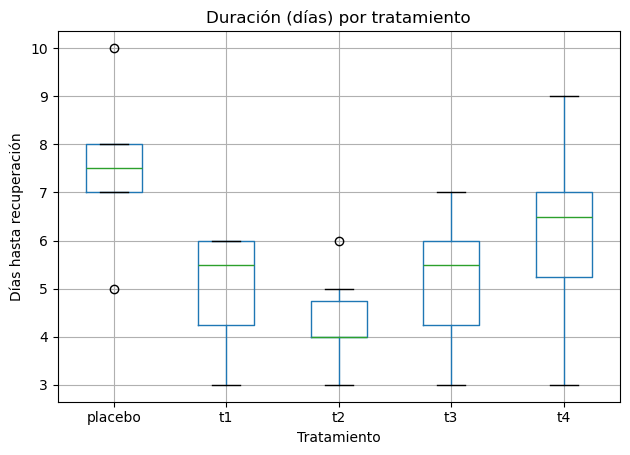

In [46]:
# ---------- PROBLEM 1 : Herpes treatments ----------
# Reshape to long format
herpes_long = herpes.melt(
    id_vars=["tratamiento"], var_name="muestra", value_name="dias"
)
# Boxplot
plt.figure()
herpes_long.boxplot(column='dias', by='tratamiento')
plt.title('Duración (días) por tratamiento')
plt.suptitle('')
plt.xlabel('Tratamiento')
plt.ylabel('Días hasta recuperación')
plt.tight_layout()

In [47]:
# Boxplot with Plotly
fig = px.box(
    herpes_long,
    x='tratamiento',
    y='dias',
    # points='all',
    title='Duración (días) por tratamiento',
    labels={'tratamiento': 'Treatment', 'dias': 'Days to Recovery'},
    template='plotly_white'
)
# fig.update_layout(
#     plot_bgcolor='Grey',
#     paper_bgcolor='Grey',
#     )
fig.show()

In [48]:
# Descriptive statistics & 95 % CI by treatment
desc1 = herpes_long.groupby('tratamiento')['dias'].agg(['mean', 'std', 'count'])
desc1['sem'] = desc1['std']/np.sqrt(desc1['count'])
t_crit = st.t.ppf(0.975, df=desc1['count']-1)
desc1['CI_low'] = desc1['mean'] - t_crit*desc1['sem']
desc1['CI_high'] = desc1['mean'] + t_crit*desc1['sem']
print('\n=== Problema 1 – Estadísticas descriptivas y CIs (95 %) ===')
print(desc1[['mean','std','CI_low','CI_high']])


=== Problema 1 – Estadísticas descriptivas y CIs (95 %) ===
                 mean       std    CI_low   CI_high
tratamiento                                        
placebo      7.500000  1.643168  5.775601  9.224399
t1           5.000000  1.264911  3.672557  6.327443
t2           4.333333  1.032796  3.249481  5.417186
t3           5.166667  1.471960  3.621939  6.711394
t4           6.166667  2.041241  4.024515  8.308818


In [49]:
# One‑way ANOVA
anova1 = smf.ols('dias ~ C(tratamiento)', data=herpes_long).fit()
anova_table1 = sm.stats.anova_lm(anova1, typ=2)
print('\n=== ANOVA ===')
print(anova_table1)


=== ANOVA ===
                   sum_sq    df         F   PR(>F)
C(tratamiento)  36.466667   4.0  3.896011  0.01359
Residual        58.500000  25.0       NaN      NaN


In [50]:
tukey = pairwise_tukeyhsd(herpes_long['dias'],
                          herpes_long['tratamiento'], alpha=0.05)
print(tukey.summary())


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
placebo     t1     -2.5 0.0628 -5.0938  0.0938  False
placebo     t2  -3.1667 0.0113 -5.7604 -0.5729   True
placebo     t3  -2.3333 0.0927 -4.9271  0.2604  False
placebo     t4  -1.3333  0.566 -3.9271  1.2604  False
     t1     t2  -0.6667  0.941 -3.2604  1.9271  False
     t1     t3   0.1667 0.9997 -2.4271  2.7604  False
     t1     t4   1.1667 0.6811 -1.4271  3.7604  False
     t2     t3   0.8333  0.877 -1.7604  3.4271  False
     t2     t4   1.8333 0.2615 -0.7604  4.4271  False
     t3     t4      1.0 0.7881 -1.5938  3.5938  False
-----------------------------------------------------


## Problema 2

In [51]:
pres = pd.read_csv(f'{DATA_PATH}presion.csv')
pres['diff'] = pres['cuatro semanas'] - pres['linea base']
n = len(pres)

In [52]:
t_stat, p = st.ttest_rel(pres['cuatro semanas'], pres['linea base'])
mean_d = pres['diff'].mean()
se_d   = pres['diff'].std(ddof=1)/np.sqrt(n)
ci95 = st.t.interval(0.95, df=n-1, loc=mean_d, scale=se_d)
print('\n=== Problema 2 – Estadísticas descriptivas ===')
print(f'Mean difference: {mean_d:.2f}, SE: {se_d:.2f}, t-statistic: {t_stat:.2f}, p-value: {p:.4f}')
print(f'95% CI: {ci95[0]:.2f} to {ci95[1]:.2f}')



=== Problema 2 – Estadísticas descriptivas ===
Mean difference: -2.95, SE: 0.79, t-statistic: -3.72, p-value: 0.0019
95% CI: -4.63 to -1.27


In [53]:
will_stat, will_p_val = st.wilcoxon(pres["cuatro semanas"], pres["linea base"])

import numpy as np

# Bootstrap 95 % CI for non‑parametric median difference
np.random.seed(0)
boot_means = [
    np.mean(np.random.choice(pres["diff"], size=n, replace=True)) for _ in range(10000)
]
ci_boot = np.percentile(boot_means, [2.5, 97.5])

print('\n=== Wilcoxon signed‑rank ===')
print(f'W = {will_stat:.3f}, p-value = {will_p_val:.4f}')
print(f'Bootstrap 95 % CI for mean diff = {ci_boot}')


=== Wilcoxon signed‑rank ===
W = 12.000, p-value = 0.0038
Bootstrap 95 % CI for mean diff = [-4.49185294 -1.47880882]


## Problema 3

In [54]:
# ---------- PROBLEM 3 : Jet engine thrust ----------
# a) Null (intercept‑only) model
y = jet['y']
null_model = sm.OLS(y, np.ones(len(y))).fit()
intercept = null_model.params[0]
print('\n=== Problem 3a – Null model ===')
print(f'Intercept (null model): {intercept:.2f}')





=== Problem 3a – Null model ===
Intercept (null model): 2.37


/tmp/ipykernel_296539/3358742644.py:5: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [55]:
# b) EDA and Exploratory correlations
print(jet.describe())
# Combined boxplot for all variables
jet_long = jet.melt(value_vars=['x1', 'x2', 'x3', 'x4', 'x5', 'y'],
                    var_name='Variable', value_name='Value')

fig = px.box(
    jet_long,
    x='Variable',
    y='Value',
    title='Boxplots of all variables',
    template='plotly_white',
    width=PLOT_WIDTH,
    height=PLOT_HEIGHT
)
fig.show()

# Scatter plots of y vs each x variable
for col in ['x1', 'x2', 'x3', 'x4', 'x5']:
    fig = px.scatter(
        jet,
        x=col,
        y='y',
        trendline='ols',  # Adds a linear regression line
        title=f'y vs {col}',
        labels={col: col, 'y': 'y'},
        template='plotly_white',
        width=PLOT_WIDTH,
        height=PLOT_HEIGHT
    )
    fig.show()

corrs = jet[['x1','x2','x3','x4','x5','y']].corr(method='pearson')['y'].drop('y')
print('\n=== Problema 3 – Correlaciones con y ===')
print(corrs)

             obs         x1        x2         x3         x4        x5  \
count  25.000000  25.000000  25.00000  25.000000  25.000000  25.00000   
mean   13.000000   6.480000   8.08000   4.920000   4.640000  38.00000   
std     7.359801   4.224137   5.93661   2.722132   2.464413  28.06243   
min     1.000000   2.000000   2.00000   2.000000   2.000000   0.00000   
25%     7.000000   3.000000   4.00000   3.000000   3.000000  25.00000   
50%    13.000000   5.000000   6.00000   4.000000   4.000000  50.00000   
75%    19.000000   8.000000  10.00000   8.000000   6.000000  50.00000   
max    25.000000  16.000000  24.00000  12.000000  12.000000  75.00000   

               y  
count  25.000000  
mean    2.372080  
std     2.939697  
min     0.201000  
25%     0.379000  
50%     0.806000  
75%     3.345000  
max     9.210000  



=== Problema 3 – Correlaciones con y ===
x1   -0.250791
x2    0.525052
x3    0.427381
x4   -0.158487
x5   -0.057719
Name: y, dtype: float64


In [56]:
# c) Full model (α=0.01)
X_full = sm.add_constant(jet[['x1','x2','x3','x4','x5']])
full_model = sm.OLS(y, X_full).fit()
print('\n=== Full linear model ===')
print(full_model.summary())


=== Full linear model ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     8.155
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           0.000298
Time:                        20:41:45   Log-Likelihood:                -47.594
No. Observations:                  25   AIC:                             107.2
Df Residuals:                      19   BIC:                             114.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0622    

In [57]:
# Variable selection (backward, drop p>0.01)
vars_selected = ['x1','x2','x3','x4','x5']
while True:
    X_sel = sm.add_constant(jet[vars_selected])
    mod = sm.OLS(y, X_sel).fit()
    pvals = mod.pvalues.drop('const')
    worst_p = pvals.max()
    if worst_p > 0.01:
        worst_var = pvals.idxmax()
        vars_selected.remove(worst_var)
    else:
        model_sel = mod
        break

print('\n=== Selected model (α=0.01) ===')
print(model_sel.summary())


=== Selected model (α=0.01) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     8.754
Date:                Wed, 11 Jun 2025   Prob (F-statistic):            0.00704
Time:                        20:41:45   Log-Likelihood:                -57.889
No. Observations:                  25   AIC:                             119.8
Df Residuals:                      23   BIC:                             122.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.27

In [58]:
# e) Compare vs null
f_stat, p_f, _ = model_sel.compare_f_test(null_model)
print(f'\nF‑test vs null: F = {f_stat:.3f}, p = {p_f:.5f}')


F‑test vs null: F = 8.754, p = 0.00704


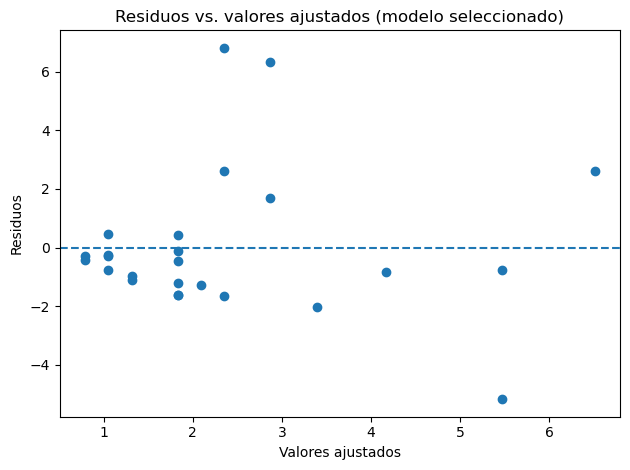

In [59]:
# f) Diagnostics – residual plot
plt.figure()
plt.scatter(model_sel.fittedvalues, model_sel.resid)
plt.axhline(0, linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs. valores ajustados (modelo seleccionado)')
plt.tight_layout()

In [60]:
resid_df = pd.DataFrame({
    "Fitted values": model_sel.fittedvalues,
    "Residuals": model_sel.resid
})

fig = px.scatter(
    resid_df,
    x="Fitted values",
    y="Residuals",
    title="Residuos vs. valores ajustados (modelo seleccionado)",
    labels={"Fitted values": "Valores ajustados", "Residuals": "Residuos"},
    template="plotly_white",
    width = PLOT_WIDTH, 
    height = PLOT_HEIGHT
)
fig.add_hline(y=0, line_dash="dash", line_color="gray")

fig.show()

In [61]:
# g) Log10 transform (remove x5)
jet_log = jet.copy()
jet_log['y_log'] = np.log10(jet_log['y'])
for col in ['x1','x2','x3','x4']:
    jet_log[col+'_log'] = np.log10(jet_log[col])

X_log = sm.add_constant(jet_log[['x1_log','x2_log','x3_log','x4_log']])
model_log = sm.OLS(jet_log['y_log'], X_log).fit()
print('\n=== Log‑transformed model ===')
print(model_log.summary())


=== Log‑transformed model ===
                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     28.93
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           4.59e-08
Time:                        20:41:45   Log-Likelihood:                 4.0166
No. Observations:                  25   AIC:                             1.967
Df Residuals:                      20   BIC:                             8.061
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2873


Removed outlier (index 1, Cookʼs D = 0.899)
=== Log‑transformed model (clean) ===
                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     203.7
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           2.57e-15
Time:                        20:41:45   Log-Likelihood:                 26.385
No. Observations:                  24   AIC:                            -42.77
Df Residuals:                      19   BIC:                            -36.88
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

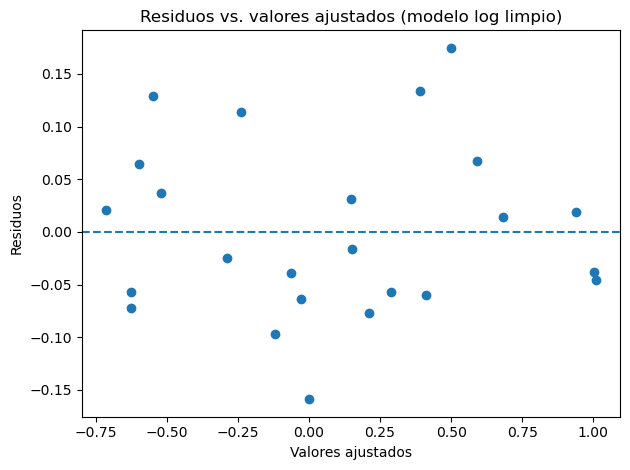

In [62]:
# h) Outlier analysis (Cookʼs distance) & refit
influence = model_log.get_influence()
cooks = influence.cooks_distance[0]
outlier_idx = np.argmax(cooks)
jet_log_clean = jet_log.drop(index=outlier_idx).reset_index(drop=True)
X_log_c = sm.add_constant(jet_log_clean[['x1_log','x2_log','x3_log','x4_log']])
model_log_c = sm.OLS(jet_log_clean['y_log'], X_log_c).fit()
print(f'\nRemoved outlier (index {outlier_idx}, Cookʼs D = {cooks[outlier_idx]:.3f})')
print('=== Log‑transformed model (clean) ===')
print(model_log_c.summary())


# Diagnostics after cleaning
plt.figure()
plt.scatter(model_log_c.fittedvalues, model_log_c.resid)
plt.axhline(0, linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs. valores ajustados (modelo log limpio)')
plt.tight_layout()

plt.show()

# Diagnostics after cleaning (Plotly)
resid_df_clean = pd.DataFrame({
    "Valores ajustados": model_log_c.fittedvalues,
    "Residuos": model_log_c.resid
})

fig = px.scatter(
    resid_df_clean,
    x="Valores ajustados",
    y="Residuos",
    title="Residuos vs. valores ajustados (modelo log limpio)",
    template="plotly_white",
    width=PLOT_WIDTH,
    height=PLOT_HEIGHT
)
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.show()